In [13]:
import baltic as bt
import pandas as pd
import numpy as np

from collections import defaultdict
from collections import Counter
from itertools import combinations
import itertools


import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as ticker

import re
import random
from scipy.stats import norm


In [14]:
tree_folder = "host_trees"
clades = ['na_avian', 'eurasian_avian', 'swine', 'human', 'canine', 'equine']

In [15]:
host_trees = {}

for clade in clades:
    
    tree = bt.loadNewick(f"{tree_folder}/{clade}.nwk", absoluteTime= False)
    
    host_trees[f"{clade}"] = tree
    

In [16]:
host_trees

{'na_avian': <baltic.baltic.tree at 0x326561030>,
 'eurasian_avian': <baltic.baltic.tree at 0x3226d5cf0>,
 'swine': <baltic.baltic.tree at 0x31d9d1fc0>,
 'human': <baltic.baltic.tree at 0x32844f130>,
 'canine': <baltic.baltic.tree at 0x31d7f06a0>,
 'equine': <baltic.baltic.tree at 0x31da4b280>}

In [17]:
reassortment_count = {}
gene_segment_counts = {name: {} for name in host_trees.keys()}
num_segment_counts = {name: {} for name in host_trees.keys()}
leaf_list = {name: [] for name in host_trees.keys()}
nodes = {}
leaves = {}

# dictionary for segment co-occurrences
segment_pair_counts = {name: defaultdict(lambda: defaultdict(int)) for name in host_trees.keys()}

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name, tree in host_trees.items():

    print(name)
    
    leaf = []
    node_count = 0
    leaf_count = 0
    count = 0
    tree_segment_counts = {segment: 0 for segment in gene_segments}
    num_segments_involved = {i: 0 for i in range(1, 8)}
    
    for k in tree.Objects:
        if k.traits.get('is_reassorted'):
            
            raw_segments = k.traits["rea"]
            is_uncertain = all([g_str.startswith('_') for g_str in raw_segments.split('-')])
            
            lst = [seg.split("(")[0].lstrip('_') for seg in raw_segments.split("-")]
            num_segments_involved[len(lst)] += 1
            count += 0.5 if is_uncertain else 1
            
            for seg in lst:
                tree_segment_counts[seg] += 0.5 if seg.startswith('_') else 1
                
            if k.is_node():
                node_count += 0.5 if is_uncertain else 1
            else:
                leaf_count += 0.5 if is_uncertain else 1
                leaf.append(k.name)
            
            # counting segment pairs (combinations of 2)
            if len(lst) > 1:
                for seg1, seg2 in combinations(lst, 2):
                    # increment both directions for easy access
                    segment_pair_counts[name][seg1][seg2] += 1
                    segment_pair_counts[name][seg2][seg1] += 1
    
    leaf_list[name] = leaf
    reassortment_count[name] = count
    nodes[name] = node_count
    leaves[name] = leaf_count
    gene_segment_counts[name] = tree_segment_counts
    num_segment_counts[name] = num_segments_involved

na_avian
eurasian_avian
swine
human
canine
equine


In [18]:
num_segment_counts

{'na_avian': {1: 444, 2: 117, 3: 38, 4: 16, 5: 8, 6: 3, 7: 0},
 'eurasian_avian': {1: 310, 2: 69, 3: 21, 4: 13, 5: 2, 6: 0, 7: 0},
 'swine': {1: 184, 2: 53, 3: 33, 4: 11, 5: 12, 6: 11, 7: 3},
 'human': {1: 48, 2: 4, 3: 2, 4: 2, 5: 3, 6: 3, 7: 1},
 'canine': {1: 6, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0},
 'equine': {1: 2, 2: 1, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0}}

In [19]:
gene_segment_counts

{'na_avian': {'NA': 173,
  'NP': 131,
  'NS': 100,
  'PB1': 111,
  'PB2': 117,
  'MP': 99,
  'PA': 183},
 'eurasian_avian': {'NA': 148,
  'NP': 75,
  'NS': 104,
  'PB1': 57,
  'PB2': 95,
  'MP': 42,
  'PA': 52},
 'swine': {'NA': 60,
  'NP': 91,
  'NS': 97,
  'PB1': 64,
  'PB2': 80,
  'MP': 96,
  'PA': 92},
 'human': {'NA': 10,
  'NP': 16,
  'NS': 10,
  'PB1': 12,
  'PB2': 36,
  'MP': 11,
  'PA': 15},
 'canine': {'NA': 1, 'NP': 2, 'NS': 2, 'PB1': 2, 'PB2': 1, 'MP': 2, 'PA': 1},
 'equine': {'NA': 1, 'NP': 0, 'NS': 2, 'PB1': 1, 'PB2': 0, 'MP': 0, 'PA': 0}}

In [20]:
segment_pair_counts

{'na_avian': defaultdict(<function __main__.<dictcomp>.<lambda>()>,
             {'NA': defaultdict(int,
                          {'PB1': 24,
                           'PA': 28,
                           'NP': 21,
                           'MP': 20,
                           'NS': 19,
                           'PB2': 19}),
              'PB1': defaultdict(int,
                          {'NA': 24,
                           'PA': 29,
                           'NP': 29,
                           'MP': 29,
                           'NS': 14,
                           'PB2': 26}),
              'PA': defaultdict(int,
                          {'NA': 28,
                           'PB1': 29,
                           'NP': 29,
                           'PB2': 21,
                           'NS': 19,
                           'MP': 20}),
              'NP': defaultdict(int,
                          {'NA': 21,
                           'PA': 29,
                           'PB1'

Overview:
----------

The following simulation generates a null distribution of reassortment events among influenza gene segments.

It models how often different segments and pairs of segments would be expected to appear in reassortment
events if reassortment occurred purely at random.

These simulated averages serve as a null expectation, allowing comparison to real reassortment data
to identify segments or segment pairs that co-occur more or less often than expected by chance.

Functions:
----------
1. simulate_single_run():
   - For each event size (e.g. 1, 2, 3 segments per event), randomly samples that many segments
     from the list of possible gene segments (without replacement).
   - Each draw represents a single reassortment event.
   - Returns a dictionary mapping event IDs (e.g. 'rea1', 'rea2', ...) to lists of involved segments.

2. simulate_null_distributions():
   - Runs the single-run simulation n_sims amount of times.
   - Each replicate is initialized with a unique seed (seed + i) for reproducible randomness.
   - Returns a dictionary of all replicate simulations.

3. aggregate_sim_results() and other helper functions:
   - Counts how often each segment participates in reassortments across simulations.
   - Counts how often each pair of segments co-occurs in the same event.
   - Averages these counts across all simulations to produce expected frequencies under random reassortment.

In [21]:
# helper functions for running the segment null distribution simulations

def count_segment_occurrences(events):
    """
    Count how many times each segment occurs in a set of reassortment events.
    """
    segment_counts = Counter()
    for segs in events.values():
        for seg in segs:
            segment_counts[seg] += 1
    return segment_counts

def count_cooccurrences(events):
    """
    Count pairwise co-occurrences in simulated events.
    events: dict of {rea#: [seg1, seg2, ...]}
    Returns: Counter with pairs as keys and counts as values.
    """
    pair_counts = Counter()
    for segs in events.values():
        if len(segs) > 1:  # only events with >1 segments
            # all unique pairs in the event
            for a, b in itertools.combinations(sorted(segs), 2):
                pair_counts[(a, b)] += 1
    return pair_counts


def plot_segment_counts(segment_counts, title):
    """
    Plot a bar chart of segment occurrences.
    """
    
    colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']
    
    segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']
    counts = [segment_counts.get(seg, 0) for seg in segments]

    plt.figure(figsize=(10,6))
    plt.bar(segments, counts, color=plt.cm.tab20.colors[:len(segments)])
    plt.ylabel("Reassortment count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_cooccurrences(pair_counts, title):
    """
    Plot a bar chart of co-occurrence counts.
    """
    pairs = ['{},{}'.format(a, b) for (a, b) in pair_counts.keys()]
    counts = list(pair_counts.values())

    plt.figure(figsize=(12,6))
    plt.bar(pairs, counts)
    plt.ylabel("Co-occurrence count")
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def aggregate_sim_results(sims):
    """
    Aggregate counts of segment occurrences and co-occurrences across all simulations.
    Returns:
        avg_segment_counts: dict of average occurrences per segment
        avg_pair_counts: dict of average pairwise co-occurrences
    """
    segment_sum = Counter()
    pair_sum = Counter()
    n_sims = len(sims)

    for events in sims.values():
        seg_counts = count_segment_occurrences(events)
        pair_counts = count_cooccurrences(events)

        segment_sum.update(seg_counts) # this adds the segment counts for each simulation to each other
        
        pair_sum.update(pair_counts)

    # creating a new dictionary with the average for each segment or pairs across the simulations
    
    avg_segment_counts = {seg: count / n_sims for seg, count in segment_sum.items()}
    avg_pair_counts = {pair: count / n_sims for pair, count in pair_sum.items()}

    return avg_segment_counts, avg_pair_counts


In [22]:
def simulate_single_run(segment_counts, gene_segments, seed):
    """
    Create one simulation run for a single tree.
    Returns: {'rea1': [seg,...], 'rea2': [...], ...}
    segment_counts: dict mapping n_segments -> n_events (e.g. {1:1062, 2:286, ...})
    gene_segments: list of segment names (e.g. ['NA','NP',...])
    """
    random.seed(seed)
    events = {}
    rea_idx = 1
    
    for n_segments in sorted(segment_counts.keys()):
        
        n_events = int(segment_counts[n_segments])
        
        for _ in range(n_events):
            
            # WITHOUT replacement:
            chosen = random.sample(gene_segments, k=n_segments) # uses the seed here 

            events[f"rea{rea_idx}"] = chosen
            
            rea_idx += 1
            
    return events

def simulate_null_distributions(segment_counts, gene_segments, n_sims, seed):
    """
    Produce n_sims simulations.
    Returns: {'sim1': {...}, 'sim2': {...}, ...}
    If seed is provided, each sim gets a deterministically different seed.
    """
    sims = {}
    
    for i in range(1, n_sims + 1):
        
        sim_seed =  seed + i # each simulation gets a new seed for randomness between runs but still reproducible
        sims[f"sim{i}"] = simulate_single_run(segment_counts, gene_segments, seed=sim_seed)
    
    return sims

def compare_real_vs_null(genes, real_counts, null_avg_counts, sim_counts, host):
    """
    Compare observed segment counts to null expectations.
    Returns a DataFrame with observed, expected, difference, ratio, z-score, and p-value.
    
    sim_counts: dict of lists with counts per segment across all simulations
    """
    
    data = []
    
    for gene in genes:
        
        observed = real_counts.get(gene, 0)
        expected = null_avg_counts.get(gene, 0)
        
        # expected (null results)
        counts = sim_counts[gene] 
        mean = np.mean(counts) 

        # counts is a list of reassortment events there were for each simulation
        
        # r computes how many simulated values are as extreme or more extreme than the observed value
        # by taking the abs, it is a two-sided test based on deviation from the mean
        
        # r returns a list with len(counts) populated with True or False
        
        # np.sum sums up the Trues
        
        n = len(counts) # number of simualtions, so n = 1000
        r_mean = np.sum(np.abs(counts - mean) >= np.abs(observed - mean))
        
        p_mean = (r_mean) / (n) 
        p_mean_correction = (r_mean + 1) / (n + 1)  # small-sample correction

        p_mean_multi = p_mean * 7
        p_mean_correction_multi = p_mean_correction * 7

        if p_mean_multi > 1:
            p_mean_multi = 1.0

        if p_mean_correction_multi > 1:
            p_mean_correction_multi = 1.0
        
        data.append([gene, observed, expected, p_mean_multi, p_mean_correction_multi
                    ])
    
    df = pd.DataFrame(data, columns=['Segment', 'Observed', 'Expected', 'p val', 'p val (monte carlo correction)'])
    df['host'] = host
    return df       

Number of sims: 1000
Events in sims_na_avian: 626


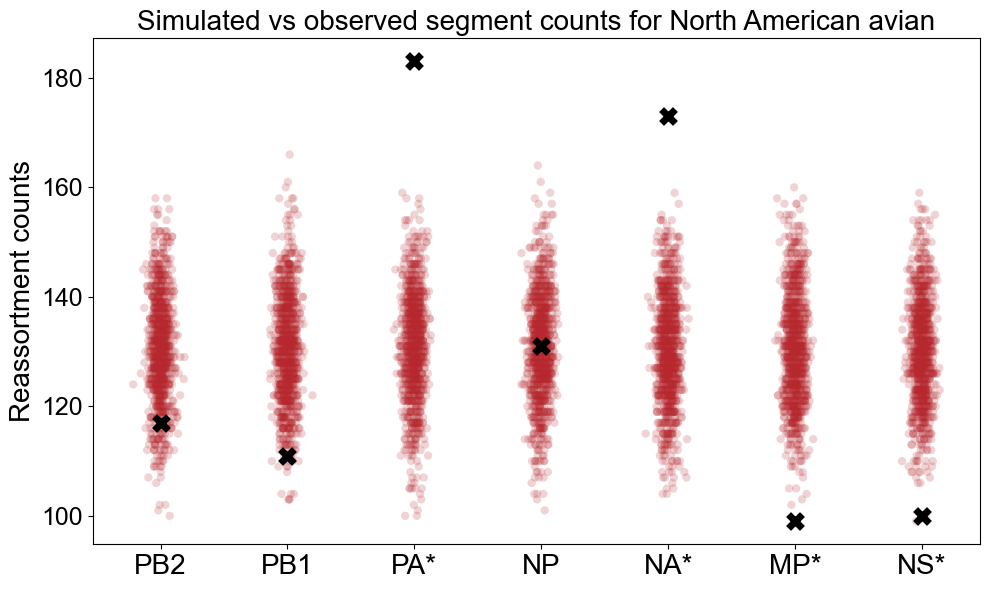

Segment  Observed      Expected       p val  p val (monte carlo correction)     host
     NA       173 130.381000000 0.000000000                     0.006993007 na_avian
     NP       131 130.931000000 1.000000000                     1.000000000 na_avian
     NS       100 130.156000000 0.014000000                     0.020979021 na_avian
    PB1       111 130.552000000 0.294000000                     0.300699301 na_avian
    PB2       117 130.585000000 1.000000000                     1.000000000 na_avian
     MP        99 130.494000000 0.000000000                     0.006993007 na_avian
     PA       183 130.901000000 0.000000000                     0.006993007 na_avian
Number of sims: 1000
Events in sims_eurasian_avian: 415


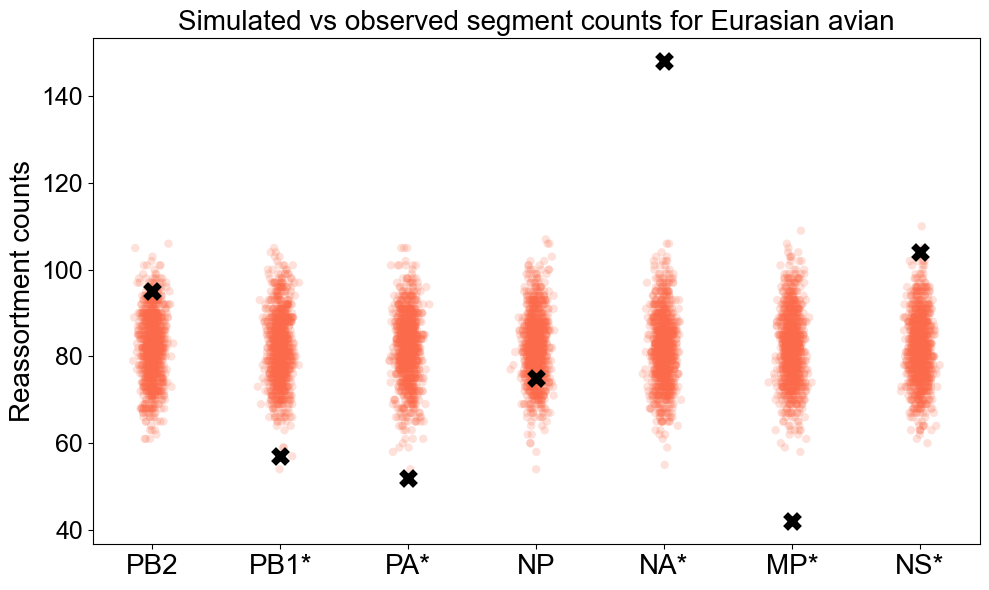

Segment  Observed     Expected       p val  p val (monte carlo correction)           host
     NA       148 81.597000000 0.000000000                     0.006993007 eurasian_avian
     NP        75 82.111000000 1.000000000                     1.000000000 eurasian_avian
     NS       104 81.718000000 0.014000000                     0.020979021 eurasian_avian
    PB1        57 81.850000000 0.014000000                     0.020979021 eurasian_avian
    PB2        95 81.904000000 0.672000000                     0.678321678 eurasian_avian
     MP        42 81.782000000 0.000000000                     0.006993007 eurasian_avian
     PA        52 82.038000000 0.000000000                     0.006993007 eurasian_avian
Number of sims: 1000
Events in sims_swine: 307


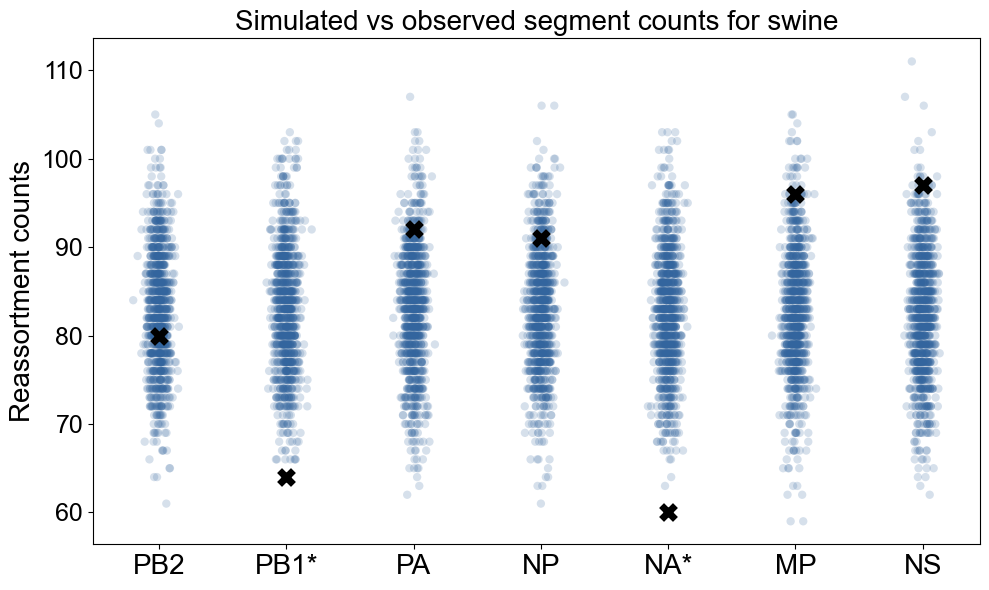

Segment  Observed     Expected       p val  p val (monte carlo correction)  host
     NA        60 82.647000000 0.000000000                     0.006993007 swine
     NP        91 83.037000000 1.000000000                     1.000000000 swine
     NS        97 82.451000000 0.259000000                     0.265734266 swine
    PB1        64 82.915000000 0.035000000                     0.041958042 swine
    PB2        80 83.018000000 1.000000000                     1.000000000 swine
     MP        96 82.823000000 0.518000000                     0.524475524 swine
     PA        92 83.109000000 1.000000000                     1.000000000 swine
Number of sims: 1000
Events in sims_human: 63


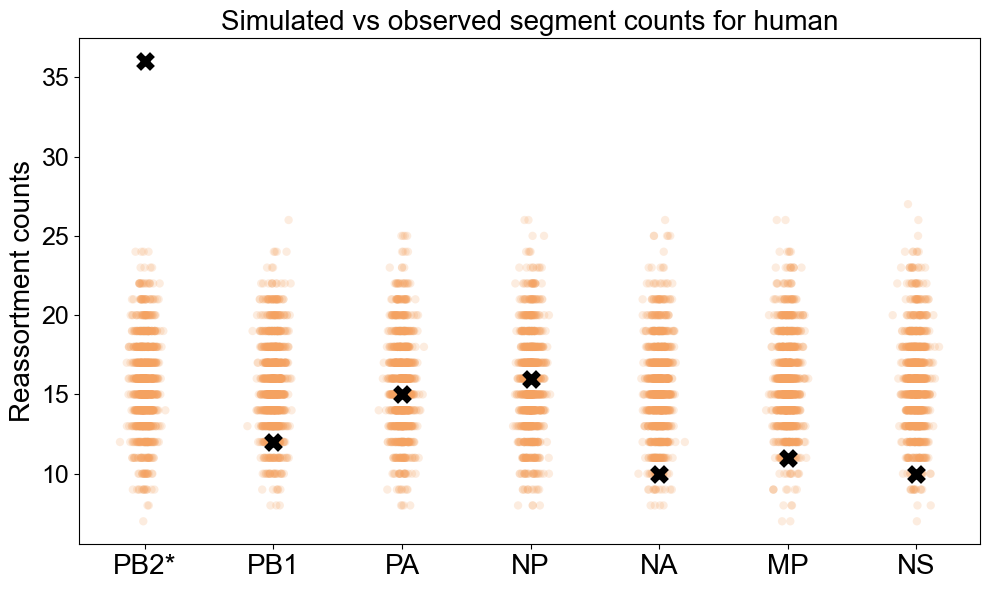

Segment  Observed     Expected       p val  p val (monte carlo correction)  host
     NA        10 15.490000000 0.714000000                     0.720279720 human
     NP        16 15.775000000 1.000000000                     1.000000000 human
     NS        10 15.842000000 0.504000000                     0.510489510 human
    PB1        12 15.718000000 1.000000000                     1.000000000 human
    PB2        36 15.687000000 0.000000000                     0.006993007 human
     MP        11 15.839000000 0.812000000                     0.818181818 human
     PA        15 15.649000000 1.000000000                     1.000000000 human
Number of sims: 1000
Events in sims_canine: 8


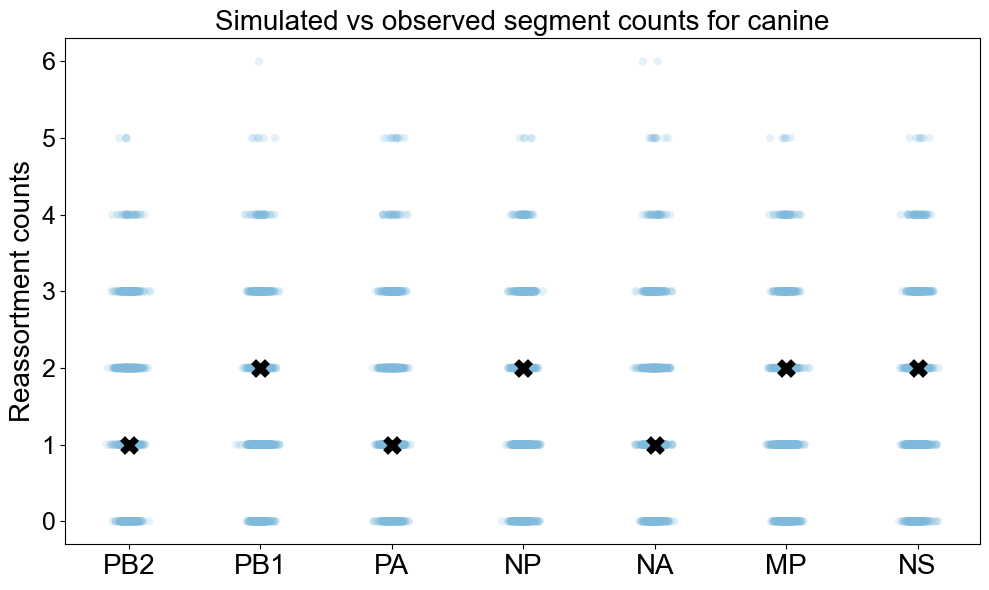

Segment  Observed    Expected       p val  p val (monte carlo correction)   host
     NA         1 1.558000000 1.000000000                     1.000000000 canine
     NP         2 1.622000000 1.000000000                     1.000000000 canine
     NS         2 1.604000000 1.000000000                     1.000000000 canine
    PB1         2 1.553000000 1.000000000                     1.000000000 canine
    PB2         1 1.552000000 1.000000000                     1.000000000 canine
     MP         2 1.544000000 1.000000000                     1.000000000 canine
     PA         1 1.567000000 1.000000000                     1.000000000 canine
Number of sims: 1000
Events in sims_equine: 3


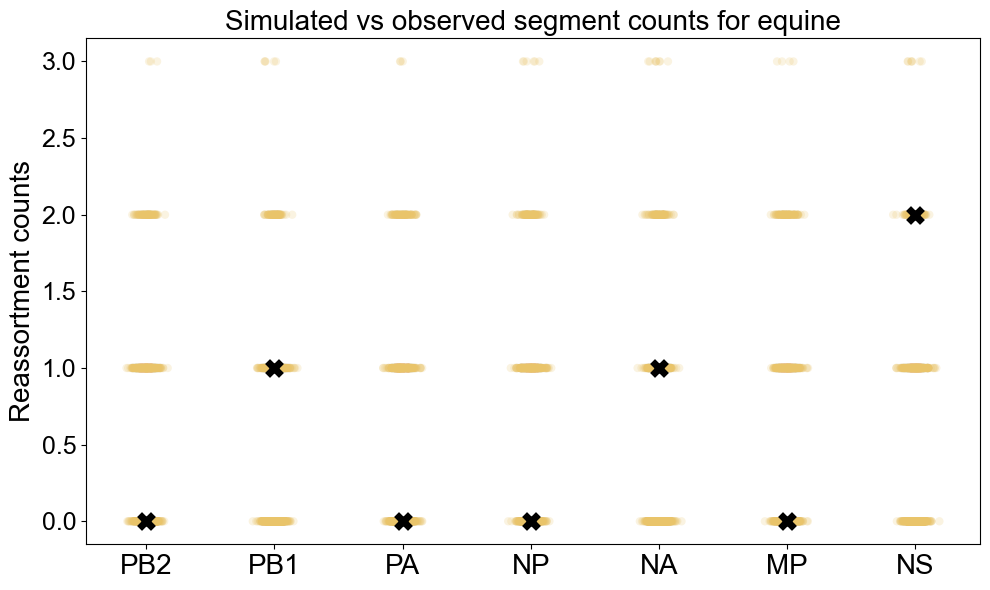

Segment  Observed    Expected       p val  p val (monte carlo correction)   host
     NA         1 0.576000000 1.000000000                     1.000000000 equine
     NP         0 0.599000000 1.000000000                     1.000000000 equine
     NS         2 0.554000000 0.574000000                     0.580419580 equine
    PB1         1 0.558000000 1.000000000                     1.000000000 equine
    PB2         0 0.576000000 1.000000000                     1.000000000 equine
     MP         0 0.570000000 1.000000000                     1.000000000 equine
     PA         0 0.567000000 1.000000000                     1.000000000 equine


In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 40
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18

genes = ['PB2', 'PB1', 'PA', 'NP', 'NA', 'MP', 'NS']


host_colors = {
    "na_avian": "#b6282e",
    "eurasian_avian": "#fb6a4a", 
    "swine": "#33659e",
    "human": "#f4a261",
    "canine": "#7fbadc",
    "equine": "#e9c46a"
}

host_names = {
    "na_avian": "North American avian",
    "eurasian_avian": "Eurasian avian",
    "swine": "swine",
    "human": "human",
    "canine": "canine",
    "equine": "equine"
}

for host in host_trees.keys():
    
    os.makedirs(f"plots/{host}", exist_ok=True)
    
    sims_tree = simulate_null_distributions(num_segment_counts[host], genes, n_sims=1000, seed=51)

    avg_segment_counts, avg_pair_counts = aggregate_sim_results(sims_tree)
    
    print("Number of sims:", len(sims_tree))
    print(f"Events in sims_{host}:", len(sims_tree['sim1']))
    
    sim_counts = {seg: [] for seg in genes}

    for events in sims_tree.values():
        counts = count_segment_occurrences(events) 
        for seg in genes:
            sim_counts[seg].append(counts.get(seg, 0))
    
    comparison_df = compare_real_vs_null(gene_segments, gene_segment_counts[host], avg_segment_counts, sim_counts, host)
    
    xticklabels = []
    for seg in genes:
        seg_row = comparison_df[comparison_df['Segment'] == seg]
        if not seg_row.empty:
            p_val = seg_row['p val (monte carlo correction)'].values[0]
            if p_val < 0.05:
                xticklabels.append(f"{seg}*")
            else:
                xticklabels.append(seg)
        else:
            xticklabels.append(seg)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_vals = np.arange(len(genes))
    
    color = host_colors[host]
    
    for i, seg in enumerate(genes):
        y = sim_counts[seg]
        
        x_jitter = np.random.normal(loc=i, scale=0.05, size=len(y))
        
        ax.scatter(x_jitter, y, color=color, alpha=0.2, edgecolor='none')
        
        real_val = gene_segment_counts[host].get(seg, 0)
        ax.scatter(i, real_val, color='black', marker='x', s=100, linewidths=5)
    
    ax.set_xticks(x_vals)
    ax.set_xticklabels(xticklabels, fontsize=20)
    ax.set_ylabel("Reassortment counts", fontsize=20)
    ax.set_title(f"Simulated vs observed segment counts for {host_names[host]}", fontsize=20)
    plt.tight_layout()
    plt.savefig(f"plots/{host}/segment_dist.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    print(comparison_df.to_string(
        index=False,
        float_format='{:.9f}'.format
    ))

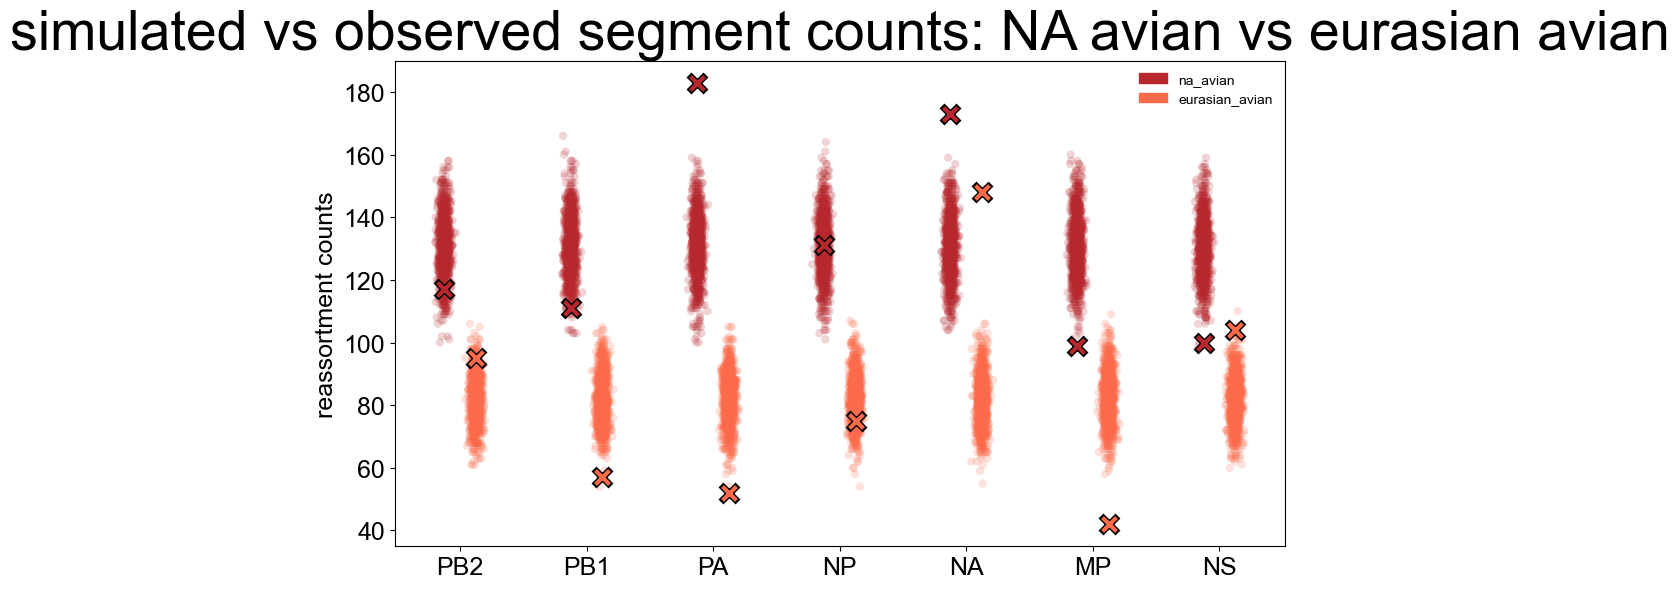

In [24]:
avian_hosts = ["na_avian", "eurasian_avian"]
os.makedirs("plots/avian_combined", exist_ok=True)

avian_sims = {}
avian_sim_counts = {}
for host in avian_hosts:
    sims_tree = simulate_null_distributions(num_segment_counts[host], genes, n_sims=1000, seed=51)
    sim_counts = {seg: [] for seg in genes}
    for events in sims_tree.values():
        counts = count_segment_occurrences(events)
        for seg in genes:
            sim_counts[seg].append(counts.get(seg, 0))
    avian_sim_counts[host] = sim_counts

fig, ax = plt.subplots(figsize=(10, 6))

x_vals = np.arange(0, len(genes) * 2, 2)  # 0, 2, 4, 6...
offsets = {"na_avian": -0.25, "eurasian_avian": 0.25}

for host in avian_hosts:
    color = host_colors[host]
    offset = offsets[host]

    for i, seg in zip(x_vals, genes):
        y = avian_sim_counts[host][seg]
        x_jitter = np.random.normal(loc=i + offset, scale=0.05, size=len(y))
        ax.scatter(x_jitter, y, color=color, alpha=0.2, edgecolor='none')

        real_val = gene_segment_counts[host].get(seg, 0)
        # black outline layer
        ax.scatter(i + offset, real_val, color='black', marker='x', s=150, linewidths=5, zorder=5)
        # colored layer on top
        ax.scatter(i + offset, real_val, color=color, marker='x', s=100, linewidths=3, zorder=6)

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=host_colors[h], label=h) for h in avian_hosts
]
ax.legend(handles=legend_handles, frameon=False)

ax.set_xticks(x_vals)
ax.set_xticklabels(genes)
ax.set_ylabel("reassortment counts")
ax.set_title("simulated vs observed segment counts: NA avian vs eurasian avian")
ax.grid(False)
plt.tight_layout()
plt.savefig("plots/avian_combined/segment_dist.pdf", dpi=300, bbox_inches="tight")
plt.show()